# Organ and tumor segmentation of a lung-cancer CT images

This notebook compares segmentation performance of two different segmentation methods using CT scan downloaded from the NCI Imaging Data Commons
(`nsclc_radiomics` collection, patient **LUNG1-133**, 184 axial slices). The segmentation performance was compared for several organs and tumor. Interactive viewers and a static overlay tool are included in this notebook.

**Segmentation methods compared** 
1. [TotalSegmentator](https://github.com/wasserth/TotalSegmentator): a
pretrained 3D nnU-Net that produces 100+ anatomical masks from CT. We restrict it to the four
organs of interest with `roi_subset`.
2. Expert and AI segmentations for this patient shipped by IDC:
    - **Expert SEG** (manual + semiautomatic): primary tumor (`Neoplasm, Primary` = GTV), lung, spinal cord
    - **AI nnU-Net SEG** (`2d`, `3d_lowres`, `3d_fullres` variants): heart, aorta, trachea, esophagus

**Pipeline**
1. Configure paths
2. Load the DICOM series (SimpleITK)
3. Run TotalSegmentator, per-organ
4. Load masks, merge the 5 lung lobes into one lung, and compute organ volumes
5. Interactive viewer (TotalSegmentator applied)
6. Run IDC-shipped segmentations, all three variants. Compare and analyze inter-model variability.
7. Using **Expert SEG**, calculated gross tumor volume (GTV) and GTV/(total volume of lung) of patient **LUNG1-133**

> Data license: this series is **CC BY-NC 3.0** (non-commercial use only).

## 0. Setup

Run once if these packages are missing. (In the prepared `.idc-venv` they are already installed.)
`torch` requires `numpy<2`.

In [3]:
# !pip install SimpleITK nibabel matplotlib "ipywidgets>=8" totalsegmentator pydicom-seg "numpy<2" "pydicom<3"
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt
from pathlib import Path
print("numpy", np.__version__)

numpy 1.26.4


## 1. Configure paths

`DICOM_DIR` is auto-detected from the IDC download created earlier
(`data/nsclc_LUNG1-133/.../CT_<SeriesInstanceUID>/`). You can download pre-made Claude skill Imaging Data Commons skill (v1.6.4; cited in item 8) to download dataset.

In [5]:
ROOT = Path.cwd()
if ROOT.name == "seg_work":          # notebook lives in seg_work/; keep all paths relative to the repo root
    ROOT = ROOT.parent
# Auto-detect the CT series folder (the one holding the .dcm files)
candidates = sorted(ROOT.glob("data/nsclc_LUNG1-133/**/CT_*"))
assert candidates, "CT folder not found — re-run the IDC download step first."
DICOM_DIR = candidates[0]

WORK     = ROOT / "seg_work"            # intermediate + outputs
CT_NIFTI = WORK / "ct.nii.gz"           # CT converted to NIfTI
SEG_DIR  = WORK / "segmentations"       # TotalSegmentator output
WORK.mkdir(exist_ok=True)

n_dcm = len(list(DICOM_DIR.glob("*.dcm")))
print("DICOM dir :", DICOM_DIR)
print("CT slices :", n_dcm)
print("Work dir  :", WORK)

DICOM dir : ./data/nsclc_LUNG1-133/nsclc_radiomics/LUNG1-133/CT_1.3.6.1.4.1.32722.99.99.6600892222510441517902761822517132550
CT slices : 184
Work dir  : ./seg_work


## 2. Load the DICOM series

SimpleITK reads the slices in physical order and assembles a 3-D volume. I keep the geometry
(spacing/orientation) and write a single NIfTI file — TotalSegmentator's masks will come back in
exactly this space, so the CT and masks stay perfectly aligned.

Arrays from `GetArrayFromImage` are indexed `[z, y, x]`, so an axial slice is `volume[z]`.

In [7]:
reader = sitk.ImageSeriesReader()
series_ids = reader.GetGDCMSeriesIDs(str(DICOM_DIR))
files = reader.GetGDCMSeriesFileNames(str(DICOM_DIR), series_ids[0])
reader.SetFileNames(files)
ct_img = reader.Execute()

ct = sitk.GetArrayFromImage(ct_img)        # [z, y, x], Hounsfield units
sx, sy, sz = ct_img.GetSpacing()           # mm

print("Volume shape (z,y,x):", ct.shape)
print(f"Voxel spacing       : {sx:.3f} x {sy:.3f} x {sz:.3f} mm")
print(f"HU range            : {ct.min()} .. {ct.max()}")

sitk.WriteImage(ct_img, str(CT_NIFTI))
print("Saved NIfTI ->", CT_NIFTI)

Volume shape (z,y,x): (184, 512, 512)
Voxel spacing       : 0.977 x 0.977 x 3.000 mm
HU range            : -1024 .. 3071
Saved NIfTI -> ./seg_work/ct.nii.gz


Saved NIfTI -> ./seg_work/ct.nii.gz


### Quick sanity check — one axial slice

Displayed with a soft-tissue window (level 40, width 400).

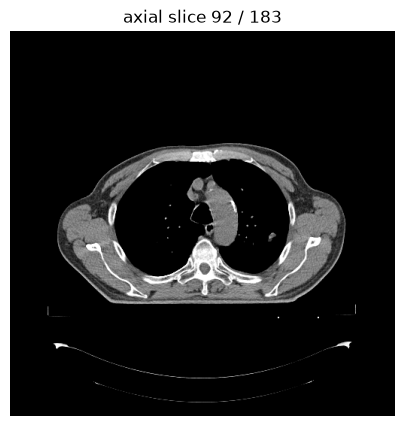

In [95]:
z0 = ct.shape[0] // 2 #section in the middle z
lo, hi = 40 - 200, 40 + 200
plt.figure(figsize=(5, 5))
plt.imshow(np.clip((ct[z0] - lo) / (hi - lo), 0, 1), cmap="gray")
plt.title(f"axial slice {z0} / {ct.shape[0]-1}")
plt.axis("off"); plt.show()

## 3. Run TotalSegmentator

Four organs were segmented in this CT image series: heart, aorta, trachea, and lung. In this cell, 5 lung lobes are segmented separately but merged in the next step. I adoped to use 3 mm model (`fast=True`) as it is much quicker on CPU and good enough for this visualization task.

In [11]:
ROI = [
    "heart", "aorta", "trachea",
    "lung_upper_lobe_left", "lung_lower_lobe_left",
    "lung_upper_lobe_right", "lung_middle_lobe_right", "lung_lower_lobe_right",
]

expected = [SEG_DIR / f"{r}.nii.gz" for r in ROI]
if all(p.exists() for p in expected):
    print("Segmentations already exist — skipping model run.")
else:
    from totalsegmentator.python_api import totalsegmentator
    totalsegmentator(
        input=str(CT_NIFTI),
        output=str(SEG_DIR),
        roi_subset=ROI,
        fast=True,
        quiet=True,
    )
    print("Done. Masks written to", SEG_DIR)

print(sorted(p.name for p in SEG_DIR.glob("*.nii.gz"))[:12])

Segmentations already exist — skipping model run.
['aorta.nii.gz', 'heart.nii.gz', 'lung_lower_lobe_left.nii.gz', 'lung_lower_lobe_right.nii.gz', 'lung_middle_lobe_right.nii.gz', 'lung_upper_lobe_left.nii.gz', 'lung_upper_lobe_right.nii.gz', 'trachea.nii.gz']


## 4. Load masks, merge lung lobes, compute volumes

Each mask is a binary volume in the CT's geometry. The five lobes are merged into a single `lung` mask,
then report each organ's volume in mLs (voxel count x voxel volume / 1000).

In [13]:
def load_mask(name):
    img = sitk.ReadImage(str(SEG_DIR / f"{name}.nii.gz"))
    return sitk.GetArrayFromImage(img).astype(bool)   # [z, y, x]

lung_lobes = ["lung_upper_lobe_left", "lung_lower_lobe_left",
              "lung_upper_lobe_right", "lung_middle_lobe_right", "lung_lower_lobe_right"]

masks = {
    "lung":    np.any([load_mask(l) for l in lung_lobes], axis=0),
    "heart":   load_mask("heart"),
    "aorta":   load_mask("aorta"),
    "trachea": load_mask("trachea"),
}

voxel_ml = (sx * sy * sz) / 1000.0
print(f"{'organ':<9}{'voxels':>12}{'volume (mL)':>14}")
for name, m in masks.items():
    n = int(m.sum())
    print(f"{name:<9}{n:>12,}{n * voxel_ml:>14.1f}")

organ          voxels   volume (mL)
lung        2,000,300        5722.9
heart         207,416         593.4
aorta         120,632         345.1
trachea        24,937          71.3


## 5. Interactive viewer

Scroll through the volume and toggle each organ overlay.

- **slice** — axial position
- **window** — CT display preset (lung / mediastinum / bone)
- **alpha** — overlay opacity
- **checkboxes** — show/hide each organ

Colors: <span style="color:#1D9E75">lung</span>,
<span style="color:#D85A30">heart</span>,
<span style="color:#534AB7">aorta</span>,
<span style="color:#BA7517">trachea</span>.

In [15]:
from ipywidgets import interact, IntSlider, FloatSlider, Dropdown, Checkbox

WINDOWS = {"lung (-600/1500)": (-600, 1500),
           "mediastinum (40/400)": (40, 400),
           "bone (300/1500)": (300, 1500)}

COLORS = {"lung": (0.114, 0.620, 0.459),
          "heart": (0.847, 0.353, 0.188),
          "aorta": (0.325, 0.290, 0.718),
          "trachea": (0.729, 0.459, 0.090)}

def view(slice_idx, window, alpha, lung, heart, aorta, trachea):
    wl, ww = WINDOWS[window]
    lo, hi = wl - ww / 2, wl + ww / 2
    base = np.clip((ct[slice_idx].astype(float) - lo) / (hi - lo), 0, 1)
    rgb = np.stack([base] * 3, axis=-1)
    for name, on in [("lung", lung), ("heart", heart), ("aorta", aorta), ("trachea", trachea)]:
        if not on:
            continue
        m = masks[name][slice_idx]
        if not m.any():
            continue
        col = COLORS[name]
        for c in range(3):
            rgb[..., c][m] = (1 - alpha) * rgb[..., c][m] + alpha * col[c]
    plt.figure(figsize=(7, 7))
    plt.imshow(rgb)
    plt.title(f"axial slice {slice_idx} / {ct.shape[0]-1}   |   {window}")
    plt.axis("off"); plt.show()

interact(
    view,
    slice_idx=IntSlider(min=0, max=ct.shape[0]-1, value=ct.shape[0]//2, description="slice"),
    window=Dropdown(options=list(WINDOWS), value="mediastinum (40/400)", description="window"),
    alpha=FloatSlider(min=0.1, max=0.9, step=0.1, value=0.45, description="alpha"),
    lung=Checkbox(value=True, description="lung"),
    heart=Checkbox(value=True, description="heart"),
    aorta=Checkbox(value=True, description="aorta"),
    trachea=Checkbox(value=True, description="trachea"),
);

interactive(children=(IntSlider(value=92, description='slice', max=183), Dropdown(description='window', index=…

## 6. Compare with the segmentations that ship with IDC

`nsclc_radiomics` ships expert and AI segmentations for this patient (downloaded to
`data/nsclc_LUNG1-133_segmentations/`):

- **Expert SEG** (manual + semiautomatic): primary tumor (`Neoplasm, Primary` = GTV), lung, spinal cord
- **AI nnU-Net SEG** (used the `3d_fullres` variant in this cell): heart, aorta, trachea, esophagus

I decoded these DICOM SEG objects into CT-aligned masks with `pydicom-seg`, then (a) overlay the
**tumor** that TotalSegmentator cannot produce, and (b) score heart/aorta/trachea agreement
(Dice) between our TotalSegmentator run and IDC's reference.

> `pydicom-seg` requires `pydicom<3` — `pip install pydicom-seg "pydicom<3"`.

In [56]:
import glob, pydicom, pydicom_seg

SEG_BASE = ROOT / "data/nsclc_LUNG1-133_segmentations"

def seg_to_masks(seg_file):
    """Decode a DICOM SEG into {label: bool array} aligned to the CT grid."""
    dcm = pydicom.dcmread(str(seg_file))
    res = pydicom_seg.SegmentReader().read(dcm)
    out = {}
    for n in res.available_segments:
        label = dcm.SegmentSequence[n - 1].get("SegmentLabel", f"seg{n}")
        seg_img = res.segment_image(n)
        r = sitk.Resample(seg_img, ct_img, sitk.Transform(),
                          sitk.sitkNearestNeighbor, 0, seg_img.GetPixelID())
        m = sitk.GetArrayFromImage(r).astype(bool)
        out[label] = out.get(label, np.zeros_like(m)) | m   # merge same-label segments (e.g. 2x Lung)
    return out

expert_file = None
variant_files = {}   # {"2d": path, "3d_lowres": path, "3d_fullres": path}
for f in glob.glob(str(SEG_BASE / "**/*.dcm"), recursive=True):
    d = pydicom.dcmread(f, stop_before_pixels=True)
    if d.Modality != "SEG":
        continue
    desc = d.get("SeriesDescription", "") or ""
    if desc == "Segmentation":
        expert_file = f
    for v in ("3d_fullres", "3d_lowres", "2d"):
        if desc.startswith(v):
            variant_files[v] = f

expert = seg_to_masks(expert_file)
nnunet_variants = {v: seg_to_masks(variant_files[v]) for v in variant_files}   # all 3 nnU-Net configs
nnunet = nnunet_variants["3d_fullres"]   # reference variant for the viewer

idc_masks = {
    "tumor":       expert["Neoplasm, Primary"],
    "lung":        expert["Lung"],
    "spinal_cord": expert["Spinal cord"],
    "heart":       nnunet["Heart"],
    "aorta":       nnunet["Aorta"],
    "trachea":     nnunet["Trachea"],
    "esophagus":   nnunet["Esophagus"],
}
print("nnU-Net variants loaded:", list(nnunet_variants))
print("\nIDC-shipped layers, 3d_fullres (mL):")
for k, v in idc_masks.items():
    print(f"  {k:12s} {v.sum() * voxel_ml:8.1f}")

nnU-Net variants loaded: ['2d', '3d_lowres', '3d_fullres']

IDC-shipped layers, 3d_fullres (mL):
  tumor             1.4
  lung           5868.3
  spinal_cord     129.3
  heart           689.6
  aorta           255.3
  trachea          72.8
  esophagus        36.9


### Comparing performance of TotalSegmentator and IDC nnU-Net configs using Dice - Three organs

Quick facts about Dice: Dice = 2·|A∩B| / (|A|+|B|), so Dice = 1.0 means identical, 0 means no overlap. ~0.8–0.9 is typical between two good
automated methods. I compare previously used **TotalSegmentator** against all three IDC **nnU-Net** configs
(2D, 3D-lowres, 3D-fullres) for the three organs all four models share (heart, aorta, trachea).

In [21]:
import pandas as pd

def dice(a, b):
    s = a.sum() + b.sum()
    return 2 * np.logical_and(a, b).sum() / s if s else float("nan")

shared = ["heart", "aorta", "trachea"]
variant_order = ["2d", "3d_lowres", "3d_fullres"]

# (1) TotalSegmentator vs each nnU-Net variant
rows = []
for organ in shared:
    row = {"organ": organ, "TotalSeg_mL": round(masks[organ].sum() * voxel_ml, 1)}
    for v in variant_order:
        row[f"Dice_vs_{v}"] = round(dice(masks[organ], nnunet_variants[v][organ.capitalize()]), 3)
    rows.append(row)
ts_vs = pd.DataFrame(rows)
print("TotalSegmentator vs IDC nnU-Net variants:")
print(ts_vs.to_string(index=False))

# Lung: the nnU-Net OAR models do NOT segment lung, so the only reference is the expert SEG.
lung_dice = dice(masks["lung"], idc_masks["lung"])
lung_ts   = masks["lung"].sum() * voxel_ml
lung_exp  = idc_masks["lung"].sum() * voxel_ml
print(f"\nLung (no nnU-Net variant -> vs expert SEG):  "
      f"TotalSeg={lung_ts:.0f} mL  expert={lung_exp:.0f} mL  "
      f"Dice={lung_dice:.3f}  vol_diff={lung_ts - lung_exp:+.0f} mL")

# (2) Inter-variant agreement among the three nnU-Net configs (model self-consistency)
print("\nInter-variant Dice (nnU-Net configs vs each other):")
pairs = [("2d", "3d_lowres"), ("2d", "3d_fullres"), ("3d_lowres", "3d_fullres")]
rows2 = []
for organ in shared:
    r = {"organ": organ}
    for a, b in pairs:
        r[f"{a}|{b}"] = round(dice(nnunet_variants[a][organ.capitalize()],
                                   nnunet_variants[b][organ.capitalize()]), 3)
    rows2.append(r)
inter = pd.DataFrame(rows2)
print(inter.to_string(index=False))

# Volume spread per organ across all four models (coefficient of variation)
print("\nVolume (mL) across models + CV:")
for organ in shared:
    vols = [masks[organ].sum() * voxel_ml] + [nnunet_variants[v][organ.capitalize()].sum() * voxel_ml
                                              for v in variant_order]
    cv = np.std(vols) / np.mean(vols) * 100
    print(f"  {organ:8s} TS={vols[0]:5.0f}  2d={vols[1]:5.0f}  lowres={vols[2]:5.0f}  "
          f"fullres={vols[3]:5.0f}  CV={cv:4.1f}%")

TotalSegmentator vs IDC nnU-Net variants:
  organ  TotalSeg_mL  Dice_vs_2d  Dice_vs_3d_lowres  Dice_vs_3d_fullres
  heart        593.4       0.793              0.786               0.791
  aorta        345.1       0.842              0.815               0.828
trachea         71.3       0.918              0.899               0.907

Lung (no nnU-Net variant -> vs expert SEG):  TotalSeg=5723 mL  expert=5868 mL  Dice=0.974  vol_diff=-145 mL

Inter-variant Dice (nnU-Net configs vs each other):
  organ  2d|3d_lowres  2d|3d_fullres  3d_lowres|3d_fullres
  heart         0.955          0.971                 0.973
  aorta         0.939          0.962                 0.958
trachea         0.947          0.970                 0.952

Volume (mL) across models + CV:
  heart    TS=  593  2d=  676  lowres=  705  fullres=  690  CV= 6.5%
  aorta    TS=  345  2d=  264  lowres=  246  fullres=  255  CV=14.3%
  trachea  TS=   71  2d=   72  lowres=   71  fullres=   73  CV= 0.9%


  organ  2d|3d_lowres  2d|3d_fullres  3d_lowres|3d_fullres
  heart         0.955          0.971                 0.973
  aorta         0.939          0.962                 0.958
trachea         0.947          0.970                 0.952

Volume (mL) across models + CV:
  heart    TS=  593  2d=  676  lowres=  705  fullres=  690  CV= 6.5%
  aorta    TS=  345  2d=  264  lowres=  246  fullres=  255  CV=14.3%
  trachea  TS=   71  2d=   72  lowres=   71  fullres=   73  CV= 0.9%


### Inter-model variability interpretation

Two distinct sources of disagreement show up above:

- **Between architectures (TotalSegmentator vs nnU-Net):** the larger gap. These are different networks
  trained on different data, so Dice in the ~0.79–0.91 range (heart < aorta < trachea) reflects genuine
  methodological differences — especially at fuzzy soft-tissue boundaries (heart pericardium, aorta wall). Compact, high-contrast structures (trachea = air) score highest.
- **Within one architecture (nnU-Net 2D vs 3D-lowres vs 3D-fullres):** smaller, but non-zero. This is the
  *configuration* sensitivity of a single method — 2D works slice-by-slice (weaker through-plane
  continuity), 3D-fullres sees the whole volume at full resolution (usually the most reliable),
  3D-lowres trades resolution for context. The volume coefficient of variation (CV) quantifies the
  total spread. Again, trachea scored highest (CV = 0.9%)
- **Lung** is a special case: the IDC nnU-Net models here segment only organs-at-risk (heart, aorta,
  trachea, esophagus), so there is **no nnU-Net lung** to compare against
— Lung is scored against the **expert SEG** instead. Agreement is the highest of any structure (**Dice ≈ 0.974**, volume 5723 mL vs
  5868 mL, a −145 mL / ~2.5% difference). That is expected: the lung is a large, high-contrast,
  air-filled organ whose boundary is unambiguous, so even different methods converge. The small volume
  deficit is most likely due to TotalSegmentator's fast 3 mm model trimming thin peripheral/peri-fissural voxels.

### Side-by-side viewer — TotalSegmentator vs IDC (with the tumor)

Use this interactive viewer below to see the results yourself! 
Left = your TotalSegmentator masks. Right = IDC's shipped masks plus the expert **tumor (GTV)** in
magenta. Same slice/window controls drive both panels. 

FYI, tumor (masked as pink) was spotted in slices 91-94.

In [24]:
from ipywidgets import interact, IntSlider, FloatSlider, Dropdown, Checkbox

CMP_COLORS = {"lung": (0.114, 0.620, 0.459), "heart": (0.847, 0.353, 0.188),
              "aorta": (0.325, 0.290, 0.718), "trachea": (0.729, 0.459, 0.090),
              "tumor": (0.92, 0.13, 0.55)}

def _overlay(ax, z, mask_set, title, window, alpha, organs, show_tumor):
    wl, ww = WINDOWS[window]; lo, hi = wl - ww/2, wl + ww/2
    base = np.clip((ct[z].astype(float) - lo) / (hi - lo), 0, 1)
    rgb = np.stack([base]*3, axis=-1)
    layers = list(organs)
    if show_tumor and "tumor" in mask_set:
        layers = layers + ["tumor"]
    for name in layers:
        if name not in mask_set:
            continue
        m = mask_set[name][z]
        if not m.any():
            continue
        col = CMP_COLORS[name]
        for c in range(3):
            rgb[..., c][m] = (1 - alpha) * rgb[..., c][m] + alpha * col[c]
    ax.imshow(rgb); ax.set_title(title, fontsize=11); ax.axis("off")

def compare(slice_idx, window, alpha, heart, aorta, lung, trachea, tumor):
    organs = [n for n, on in [("heart", heart), ("aorta", aorta),
                              ("lung", lung), ("trachea", trachea)] if on]
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 6.5))
    _overlay(axL, slice_idx, masks,     "TotalSegmentator (yours)", window, alpha, organs, False)
    _overlay(axR, slice_idx, idc_masks, "IDC shipped (+ tumor)",    window, alpha, organs, tumor)
    fig.suptitle(f"axial slice {slice_idx} / {ct.shape[0]-1}", fontsize=12)
    plt.tight_layout(); plt.show()

interact(
    compare,
    slice_idx=IntSlider(min=0, max=ct.shape[0]-1, value=ct.shape[0]//2, description="slice"),
    window=Dropdown(options=list(WINDOWS), value="mediastinum (40/400)", description="window"),
    alpha=FloatSlider(min=0.1, max=0.9, step=0.1, value=0.45, description="alpha"),
    heart=Checkbox(value=True, description="heart"),
    aorta=Checkbox(value=True, description="aorta"),
    lung=Checkbox(value=False, description="lung"),
    trachea=Checkbox(value=True, description="trachea"),
    tumor=Checkbox(value=True, description="tumor (GTV)"),
);

interactive(children=(IntSlider(value=92, description='slice', max=183), Dropdown(description='window', index=…

## 7. Tumor (GTV; Gross Tumor Volume) segmentation — adopted from Aerts. et al.

For the *tumor* specifically, I adopted the segmentation that ships with NSCLC-Radiomics. 

Clarification: This segmentation, **expert-curated GTV**, is not an AI model: the `Neoplasm, Primary` segment in the DICOM SEG (equivalently `GTV-1` in the RTSTRUCT), delineated
manually/semi-automatically for the original "Lung1" radiotherapy study.

Below I load it and report the GTV and the GTV-to-total-lung ratio (this patient has a single CT series in
NSCLC-Radiomics, so the table has one row, but the code generalizes to multi-image patients).

PatientID                                             SeriesInstanceUID  GTV_mL  total_lung_mL  GTV_to_lung_pct                                     tumor_source
LUNG1-133 1.3.6.1.4.1.32722.99.99.6600892222510441517902761822517132550   1.399         5868.3           0.0238 expert SEG: Neoplasm, Primary (= RTSTRUCT GTV-1)

GTV = 1.40 mL   total lung = 5868 mL   GTV/lung = 0.0238 %


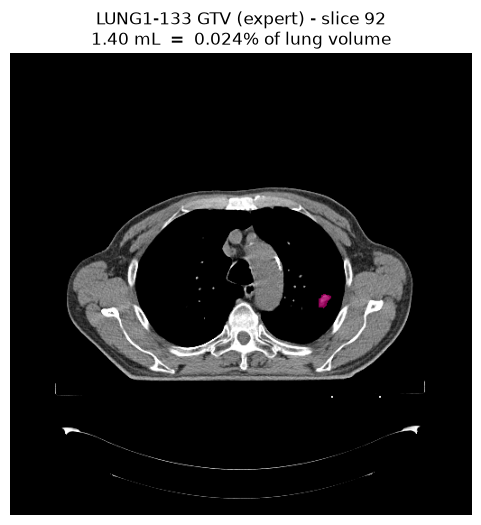

In [28]:
import pandas as pd, numpy as np, pydicom, glob

def best_slice(mask):
    return int(np.argmax(mask.reshape(mask.shape[0], -1).sum(axis=1)))

tumor      = idc_masks["tumor"]      # expert GTV (Neoplasm, Primary)
lung_total = idc_masks["lung"]       # expert lung = anatomical denominator
gtv_ml  = float(tumor.sum() * voxel_ml)
lung_ml = float(lung_total.sum() * voxel_ml)
ratio   = gtv_ml / lung_ml * 100

suid = pydicom.dcmread(sorted(glob.glob(str(DICOM_DIR / "*.dcm")))[0],
                       stop_before_pixels=True).SeriesInstanceUID
tumor_table = pd.DataFrame([{
    "PatientID":         "LUNG1-133",
    "SeriesInstanceUID": suid,
    "GTV_mL":            round(gtv_ml, 3),
    "total_lung_mL":     round(lung_ml, 1),
    "GTV_to_lung_pct":   round(ratio, 4),
    "tumor_source":      "expert SEG: Neoplasm, Primary (= RTSTRUCT GTV-1)",
}])
tumor_table.to_csv(WORK / "tumor_gtv.csv", index=False)
print(tumor_table.to_string(index=False))
print(f"\nGTV = {gtv_ml:.2f} mL   total lung = {lung_ml:.0f} mL   GTV/lung = {ratio:.4f} %")

# Visualize the GTV on the slice with the largest tumor cross-section (soft-tissue window)
z = best_slice(tumor)
lo, hi = 40 - 200, 40 + 200
base = np.clip((ct[z].astype(float) - lo) / (hi - lo), 0, 1)
rgb = np.stack([base] * 3, axis=-1)
m = tumor[z]
rgb[..., 0][m] = 0.4 * rgb[..., 0][m] + 0.6 * 0.92
rgb[..., 1][m] = 0.4 * rgb[..., 1][m]
rgb[..., 2][m] = 0.4 * rgb[..., 2][m] + 0.6 * 0.55
plt.figure(figsize=(6, 6))
plt.imshow(rgb); plt.axis("off")
plt.title(f"LUNG1-133 GTV (expert) - slice {z}\n{gtv_ml:.2f} mL  =  {ratio:.3f}% of lung volume")
plt.show()

**This patient's lung CT slices 91-94 revealed a tumor with GTV of 1.40 mL (0.024% of lung volume)**

## Extra - Static overlay tool

Use the tool below to pick slices where the organs are present and write a labelled PNG you can drop into a report.

Saved -> ./seg_work/organ_overlay_montage.png


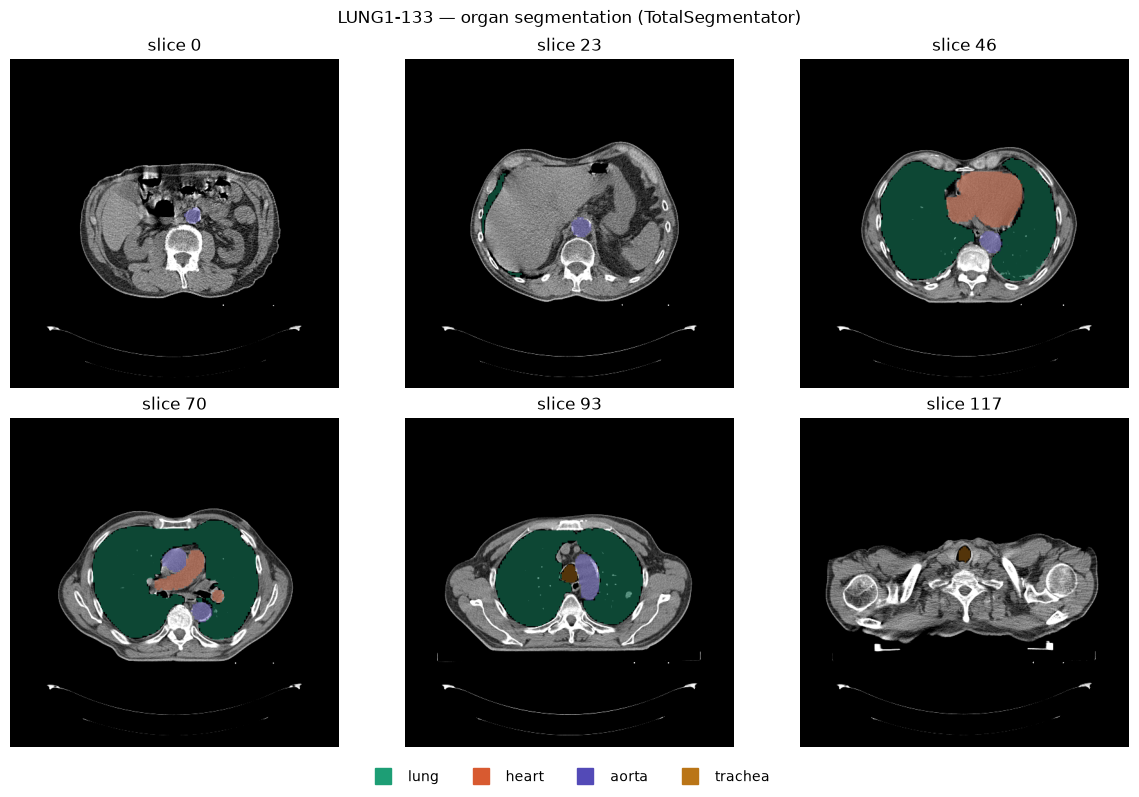

In [53]:
def overlay(slice_idx, alpha=0.45, wl=40, ww=400):
    lo, hi = wl - ww / 2, wl + ww / 2
    base = np.clip((ct[slice_idx].astype(float) - lo) / (hi - lo), 0, 1)
    rgb = np.stack([base] * 3, axis=-1)
    for name, col in COLORS.items():
        m = masks[name][slice_idx]
        for c in range(3):
            rgb[..., c][m] = (1 - alpha) * rgb[..., c][m] + alpha * col[c]
    return rgb

any_organ = np.any([m for m in masks.values()], axis=0).reshape(ct.shape[0], -1).any(axis=1)
zs = np.linspace(np.argmax(any_organ), len(any_organ) - 1 - np.argmax(any_organ[::-1]), 6).astype(int)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, z in zip(axes.ravel(), zs):
    ax.imshow(overlay(z)); ax.set_title(f"slice {z}"); ax.axis("off")
handles = [plt.Line2D([0], [0], marker="s", ls="", markersize=12, color=c, label=n)
           for n, c in COLORS.items()]
fig.legend(handles=handles, loc="lower center", ncol=4, frameon=False)
fig.suptitle("LUNG1-133 — organ segmentation (TotalSegmentator)")
fig.tight_layout(rect=[0, 0.04, 1, 1])
out = WORK / "organ_overlay_montage.png"
fig.savefig(out, dpi=110, bbox_inches="tight")
print("Saved ->", out)
plt.show()

## 8. Citations and attribution

Generated from `source_DOI` values via `idc-index` plus the canonical method papers. Cite all of these
when publishing results derived from this data. The **tumor GTV** used in Section 9 is part of the
NSCLC-Radiomics dataset (Aerts et al.) — cite that dataset when reporting GTV-derived results.

**Imaging dataset (NSCLC-Radiomics / "Lung1")**
- Aerts, H. J. W. L., Wee, L., Rios Velazquez, E., et al. (2019). *Data From NSCLC-Radiomics* (Version 4)
  [Dataset]. The Cancer Imaging Archive. https://doi.org/10.7937/K9/TCIA.2015.PF0M9REI
- Aerts, H. J. W. L., Velazquez, E. R., Leijenaar, R. T. H., et al. (2014). Decoding tumour phenotype by
  noninvasive imaging using a quantitative radiomics approach. *Nature Communications*, 5, 4006.
  https://doi.org/10.1038/ncomms5006

**The Cancer Imaging Archive (TCIA)**
- Clark, K., Vendt, B., Smith, K., et al. (2013). The Cancer Imaging Archive (TCIA): Maintaining and
  Operating a Public Information Repository. *Journal of Digital Imaging*, 26(6), 1045–1057.
  https://doi.org/10.1007/s10278-013-9622-7

**Imaging Data Commons (IDC) skill**
- Fedorov, A., Longabaugh, W. J. R., Pot, D., et al. (2023). National Cancer Institute Imaging Data
  Commons: Toward Transparency, Reproducibility, and Scalability in Imaging Artificial Intelligence.
  *RadioGraphics*, 43(12), e230180. https://doi.org/10.1148/rg.230180

**AI segmentation layers used here**
- *TotalSegmentator (this notebook's organ masks):* Wasserthal, J., Breit, H.-C., Meyer, M. T., et al.
  (2023). TotalSegmentator: Robust Segmentation of 104 Anatomical Structures in CT Images.
  *Radiology: Artificial Intelligence*, 5(5), e230024. https://doi.org/10.1148/ryai.230024
- *IDC-shipped nnU-Net annotations (the comparison masks):* Krishnaswamy, D., Bontempi, D., Clunie, D.,
  Aerts, H., & Fedorov, A. (2023). *AI-derived annotations for the NLST and NSCLC-Radiomics CT imaging
  collections* [Dataset]. Zenodo. https://doi.org/10.5281/zenodo.7473970
- *nnU-Net framework:* Isensee, F., Jaeger, P. F., Kohl, S. A. A., Petersen, J., & Maier-Hein, K. H.
  (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation.
  *Nature Methods*, 18(2), 203–211. https://doi.org/10.1038/s41592-020-01008-z

